In [13]:
!pip install yfinance matplotlib seaborn tabulate

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from tabulate import tabulate

In [14]:
tickers = ['SPY', 'QQQ', 'BND','GLD']
weights = np.array([.4,.25,.25,.10])
portfolio_value = 1_000_000.0

In [15]:
raw_data = yf.download(
    tickers, start="2020-01-01", end="2025-01-01", auto_adjust=True
)["Close"]
daily_returns = raw_data.pct_change().dropna()

weights = np.array(
    [weights[tickers.index(col)] for col in daily_returns.columns]
)


[*********************100%***********************]  4 of 4 completed


In [16]:
print("--- DATA SUMMARY ---")
print(f"Total Trading Days Downloaded: {len(daily_returns)}")
print(f"Assets Tracked: {list(daily_returns.columns)}")
print(daily_returns.head(3))

--- DATA SUMMARY ---
Total Trading Days Downloaded: 1257
Assets Tracked: ['BND', 'GLD', 'QQQ', 'SPY']
Ticker           BND       GLD       QQQ       SPY
Date                                              
2020-01-03  0.003573  0.013269 -0.009160 -0.007572
2020-01-06 -0.001186  0.010490  0.006443  0.003815
2020-01-07 -0.000832  0.003935 -0.000139 -0.002812


In [17]:
mean_returns = daily_returns.mean().values
cov_matrix = daily_returns.cov().values

L = np.linalg.cholesky(cov_matrix)

In [18]:
np.random.seed(42)
n_simulations = 10_000

uncorrelated_randoms = np.random.normal(size=(n_simulations, len(tickers)))

correlated_shocks = uncorrelated_randoms @ L.T

sim_asset_returns = mean_returns + correlated_shocks
sim_portfolio_returns = sim_asset_returns @ weights
sim_dollar_pnl = sim_portfolio_returns * portfolio_value

print("--- MONTE CARLO ENGINE COMPLETE ---")
print(f"Generated {n_simulations:,} simulated trading days.")
print(f"Worst Simulated Day (Dollar Loss): -${abs(sim_dollar_pnl.min()):,.2f}")
print(f"Best Simulated Day (Dollar Gain):   +${sim_dollar_pnl.max():,.2f}")
print(f"Average Expected Daily Return:     +${sim_dollar_pnl.mean():,.2f}")

--- MONTE CARLO ENGINE COMPLETE ---
Generated 10,000 simulated trading days.
Worst Simulated Day (Dollar Loss): -$36,486.11
Best Simulated Day (Dollar Gain):   +$38,162.86
Average Expected Daily Return:     +$446.73


In [19]:
var_95_mc = np.percentile(sim_dollar_pnl, 5)
cvar_95_mc = sim_dollar_pnl[sim_dollar_pnl <= var_95_mc].mean()

var_99_mc = np.percentile(sim_dollar_pnl, 1)
cvar_99_mc = sim_dollar_pnl[sim_dollar_pnl <= var_99_mc].mean()

port_mean = sim_dollar_pnl.mean()
port_std = sim_dollar_pnl.std()
var_95_param = port_mean - norm.ppf(0.95) * port_std
var_99_param = port_mean - norm.ppf(0.99) * port_std

print("--- TAIL RISK METRICS CALCULATED ---")
print(f"1-Day 95% Monte Carlo VaR:  -${abs(var_95_mc):,.2f}")
print(f"1-Day 95% Monte Carlo CVaR: -${abs(cvar_95_mc):,.2f}")
print(f"1-Day 99% Monte Carlo VaR:  -${abs(var_99_mc):,.2f}")
print(f"1-Day 99% Monte Carlo CVaR: -${abs(cvar_99_mc):,.2f}")
print(f"\n1-Day 99% Parametric VaR:   -${abs(var_99_param):,.2f}")

--- TAIL RISK METRICS CALCULATED ---
1-Day 95% Monte Carlo VaR:  -$15,579.64
1-Day 95% Monte Carlo CVaR: -$19,773.71
1-Day 99% Monte Carlo VaR:  -$22,783.89
1-Day 99% Monte Carlo CVaR: -$25,634.05

1-Day 99% Parametric VaR:   -$22,326.80


In [20]:
scenarios = {
    "Liquidity Crunch (Equities -9%, Tech -14%, Bonds -3%, Gold -2%)": np.array(
        [-0.03, -0.02, -0.14, -0.09]
    ),
    "Stagflation Shock (Equities -6%, Tech -8%, Bonds -5%, Gold +7%)": np.array(
        [-0.05, 0.07, -0.08, -0.06]
    ),
    "Tech Correction (Equities -3%, Tech -12%, Bonds +1%, Gold +2%)": np.array(
        [0.01, 0.02, -0.12, -0.03]
    ),
}

stress_results = []
for name, shock_vector in scenarios.items():
    pct_impact = np.dot(weights, shock_vector) * 100
    dollar_impact = (pct_impact / 100.0) * portfolio_value
    remaining_capital = portfolio_value + dollar_impact
    stress_results.append(
        [name, f"${abs(dollar_impact):,.2f}", f"{pct_impact:.2f}%", f"${remaining_capital:,.2f}"]
    )

print("--- MACRO STRESS-TEST SCENARIOS COMPLETE ---")
print(
    tabulate(
        stress_results,
        headers=["Crisis Scenario", "Drawdown ($)", "Drawdown (%)", "Remaining Liquidity"],
        tablefmt="fancy_grid",
    )
)

--- MACRO STRESS-TEST SCENARIOS COMPLETE ---
╒═════════════════════════════════════════════════════════════════╤════════════════╤════════════════╤═══════════════════════╕
│ Crisis Scenario                                                 │ Drawdown ($)   │ Drawdown (%)   │ Remaining Liquidity   │
╞═════════════════════════════════════════════════════════════════╪════════════════╪════════════════╪═══════════════════════╡
│ Liquidity Crunch (Equities -9%, Tech -14%, Bonds -3%, Gold -2%) │ $80,500.00     │ -8.05%         │ $919,500.00           │
├─────────────────────────────────────────────────────────────────┼────────────────┼────────────────┼───────────────────────┤
│ Stagflation Shock (Equities -6%, Tech -8%, Bonds -5%, Gold +7%) │ $49,500.00     │ -4.95%         │ $950,500.00           │
├─────────────────────────────────────────────────────────────────┼────────────────┼────────────────┼───────────────────────┤
│ Tech Correction (Equities -3%, Tech -12%, Bonds +1%, Gold +2%)  │ $37,5

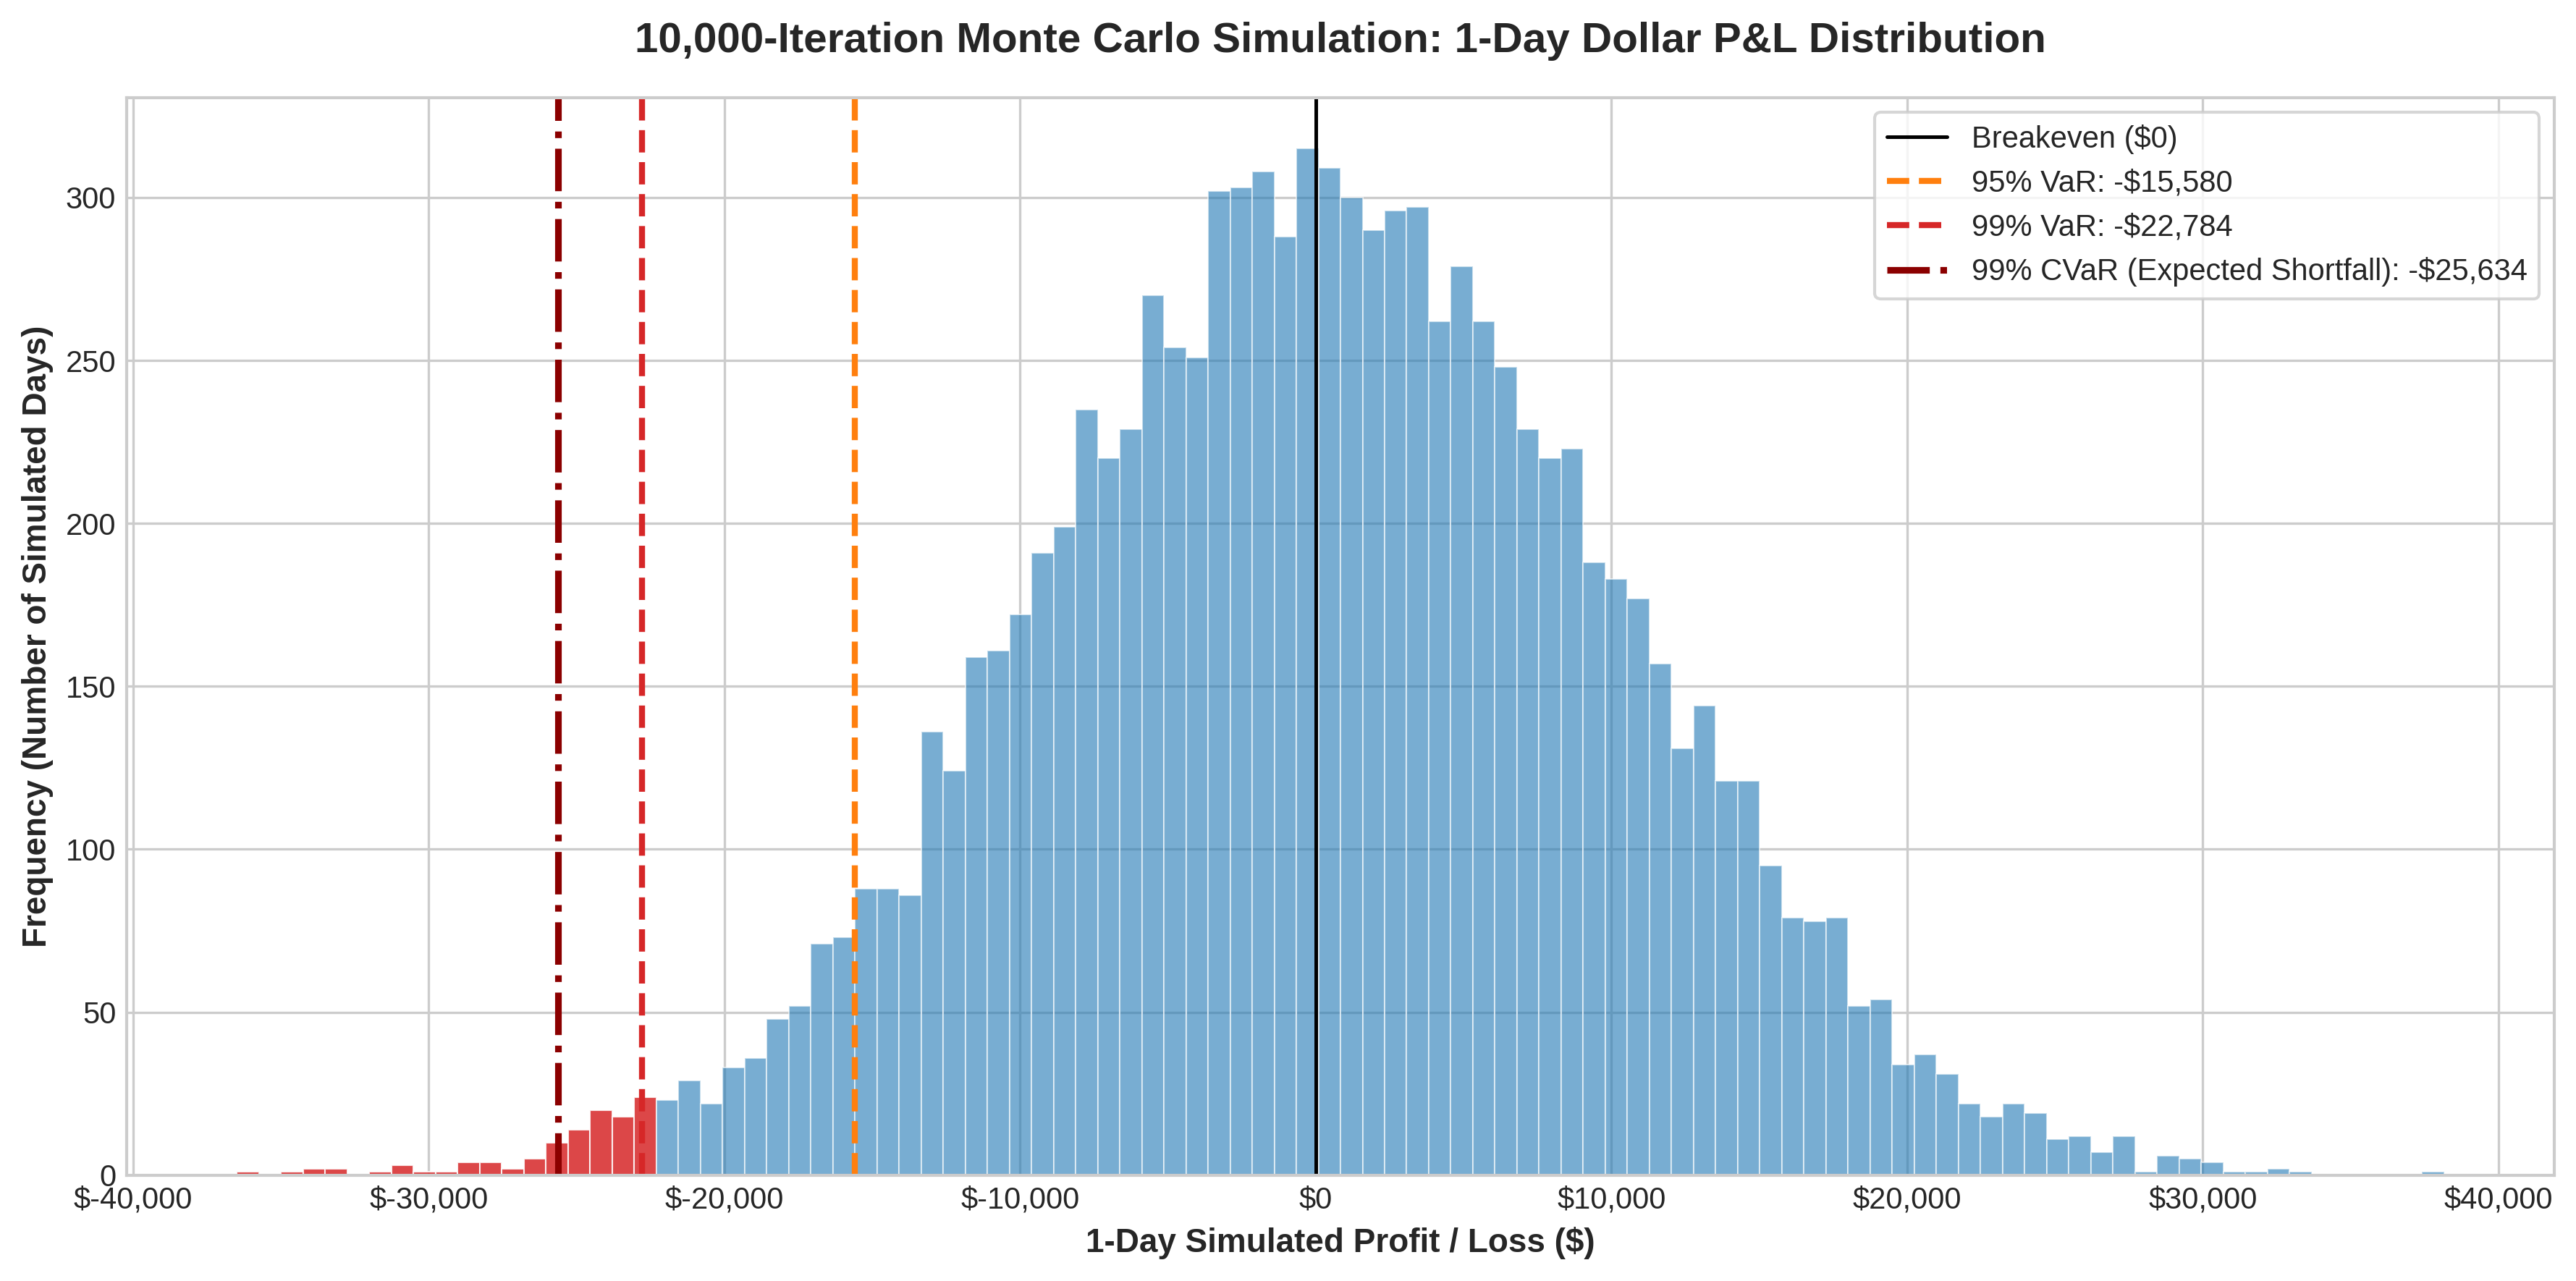

In [21]:

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)


n, bins, patches = ax.hist(
    sim_dollar_pnl, bins=100, color="#1f77b4", alpha=0.6, edgecolor="white", linewidth=0.5
)

for c, p in zip(bins, patches):
    if c <= var_99_mc:
        p.set_facecolor("#d62728")
        p.set_alpha(0.85)

ax.axvline(0, color="black", linestyle="-", linewidth=1.2, label="Breakeven ($0)")
ax.axvline(var_95_mc, color="#ff7f0e", linestyle="--", linewidth=2.0, label=f"95% VaR: -${abs(var_95_mc):,.0f}")
ax.axvline(var_99_mc, color="#d62728", linestyle="--", linewidth=2.0, label=f"99% VaR: -${abs(var_99_mc):,.0f}")
ax.axvline(cvar_99_mc, color="#8b0000", linestyle="-.", linewidth=2.2, label=f"99% CVaR (Expected Shortfall): -${abs(cvar_99_mc):,.0f}")


ax.set_title("10,000-Iteration Monte Carlo Simulation: 1-Day Dollar P&L Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("1-Day Simulated Profit / Loss ($)", fontsize=11, fontweight="bold")
ax.set_ylabel("Frequency (Number of Simulated Days)", fontsize=11, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=10)

plt.tight_layout()
plt.show()

In [22]:
summary_kpis = [
    ["Portfolio Capital Base", f"${portfolio_value:,.2f}"],
    ["Simulation Horizon", "1 Trading Day (10,000 Iterations)"],
    ["Asset Allocation", "40% SPY | 25% QQQ | 25% BND | 10% GLD"],
    ["Expected Daily Return (Mean)", f"+${sim_dollar_pnl.mean():,.2f}"],
    ["Daily Portfolio Std Deviation", f"${sim_dollar_pnl.std():,.2f}"],
    ["1-Day 95% Monte Carlo VaR", f"-${abs(var_95_mc):,.2f}"],
    ["1-Day 95% Monte Carlo CVaR", f"-${abs(cvar_95_mc):,.2f}"],
    ["1-Day 99% Monte Carlo VaR", f"-${abs(var_99_mc):,.2f}"],
    ["1-Day 99% Monte Carlo CVaR (Expected Shortfall)", f"-${abs(cvar_99_mc):,.2f}"],
    ["1-Day 99% Parametric (Gaussian) VaR", f"-${abs(var_99_param):,.2f}"],
    ["Tail-Risk Underestimation Gap (Parametric vs MC)", f"-${abs(var_99_mc - var_99_param):,.2f}"],
]

print("\n" + "="*80)
print("             EXECUTIVE RISK MANAGEMENT AUDIT REPORT")
print("="*80)
print(tabulate(summary_kpis, headers=["Metric / Parameter", "Portfolio Value"], tablefmt="fancy_grid"))

print("\n" + "="*80)
print("             DETERMINISTIC STRESS-TEST SCENARIOS")
print("="*80)
print(tabulate(stress_results, headers=["Crisis Scenario", "Drawdown ($)", "Drawdown (%)", "Remaining Liquidity"], tablefmt="fancy_grid"))


             EXECUTIVE RISK MANAGEMENT AUDIT REPORT
╒══════════════════════════════════════════════════╤═══════════════════════════════════════╕
│ Metric / Parameter                               │ Portfolio Value                       │
╞══════════════════════════════════════════════════╪═══════════════════════════════════════╡
│ Portfolio Capital Base                           │ $1,000,000.00                         │
├──────────────────────────────────────────────────┼───────────────────────────────────────┤
│ Simulation Horizon                               │ 1 Trading Day (10,000 Iterations)     │
├──────────────────────────────────────────────────┼───────────────────────────────────────┤
│ Asset Allocation                                 │ 40% SPY | 25% QQQ | 25% BND | 10% GLD │
├──────────────────────────────────────────────────┼───────────────────────────────────────┤
│ Expected Daily Return (Mean)                     │ +$446.73                              │
├────────────────